In [2]:
import numpy as np


def read_latency_data(file, ignore):
    data = {"end_to_end": [], "service": []}
    with open(file, "r") as file:
        for line in file.readlines():
            span, latency = line.strip().split(",")
            assert span in data.keys()
            data[span].append(int(latency))
    for span in data.keys():
        n_ignore = int(len(data[span]) * ignore)
        data[span] = data[span][n_ignore:]
    return data 


def get_pctl(data, pctl):
    data = np.sort(data)
    tail = np.percentile(data, pctl).astype(int)
    return tail

In [9]:
rps_values = list(range(100, 2001, 100))
e2e_data = {
    "rps": [],
    "fcfs": [],
    "masa": [],
}
svc_data = {
    "rps": [],
    "fcfs": [],
    "masa": [],
}

pctl = 99
for rps in rps_values:
    e2e_data["rps"].append(rps)
    svc_data["rps"].append(rps)

    file = f"r{rps}-fcfs.csv"
    data = read_latency_data(file, ignore=0.01)
    e2e_data["fcfs"].append(get_pctl(data["end_to_end"], pctl))
    svc_data["fcfs"].append(get_pctl(data["service"], pctl))

    file = f"r{rps}-masa.csv"
    data = read_latency_data(file, ignore=0.01)
    e2e_data["masa"].append(get_pctl(data["end_to_end"], pctl))
    svc_data["masa"].append(get_pctl(data["service"], pctl))

print(e2e_data)
print()
print(svc_data)

{'rps': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000], 'fcfs': [40619, 41864, 45004, 47420, 49811, 55802, 58892, 64643, 69275, 77581, 84903, 95884, 108684, 125452, 151292, 192669, 250280, 388562, 669720, 869853], 'masa': [40198, 41720, 44136, 46147, 48225, 52755, 54509, 59286, 61971, 68271, 73898, 81572, 91202, 108122, 129444, 153529, 208940, 298421, 527803, 647397]}

{'rps': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000], 'fcfs': [9040, 9490, 9334, 9728, 10113, 11360, 11355, 13157, 14312, 16006, 18255, 21304, 24124, 29158, 34796, 43388, 56282, 77546, 164788, 247810], 'masa': [9040, 9508, 9456, 9828, 10408, 11753, 12147, 13391, 15219, 18291, 21548, 25579, 29357, 37813, 42848, 54680, 73608, 97291, 178448, 239415]}


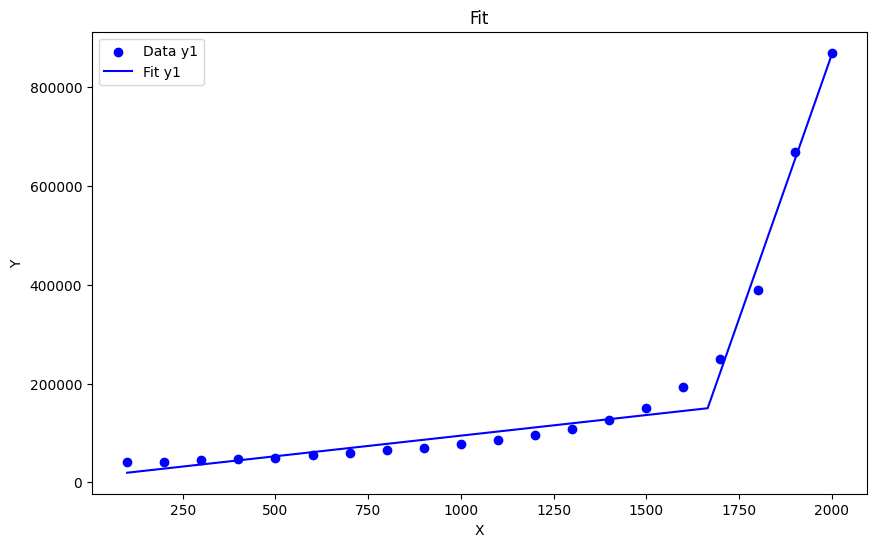

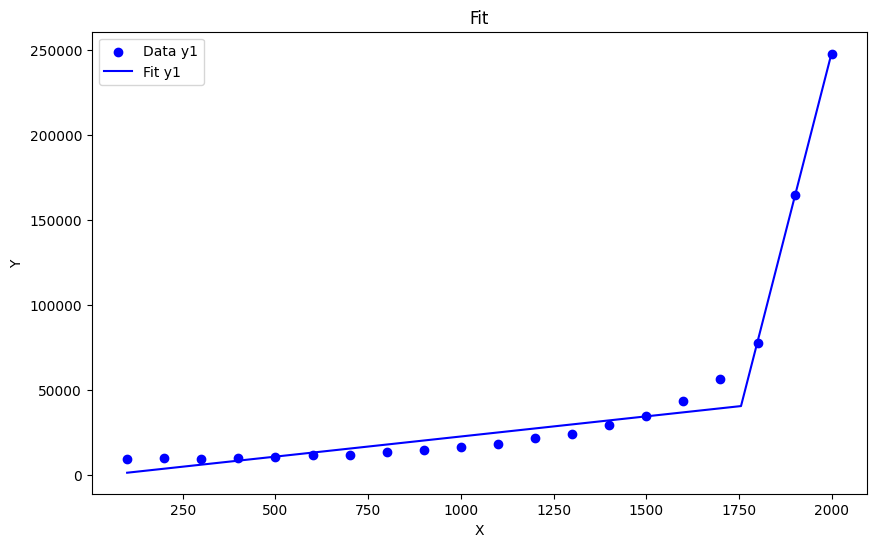

40000 348 4000 222 

45000 408 4500 243 

50000 468 5000 265 

55000 528 5500 286 

60000 588 6000 307 

65000 648 6500 328 

70000 708 7000 349 

75000 768 7500 370 

80000 828 8000 391 

85000 888 8500 412 

90000 948 9000 433 

95000 1008 9500 454 

100000 1068 10000 475 

105000 1128 10500 496 

110000 1188 11000 518 

115000 1248 11500 539 

120000 1308 12000 560 

125000 1368 12500 581 

130000 1427 13000 602 



In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pwlf
from scipy.optimize import fsolve


def plot(data):
    n_points = len(data["rps"])
    x = np.array(data["rps"][:n_points])
    y1 = np.array(data["fcfs"][:n_points])
    # y2 = np.array(data["masa"][:n_points])

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y1, color="blue", label="Data y1")
    # plt.scatter(x, y2, color="green", label="Data y2")

    fit = pwlf.PiecewiseLinFit(x, y1)
    fit.fit(2)
    x_hat = np.linspace(min(x), max(x), num=10000)
    y_hat = fit.predict(x_hat)
    plt.plot(x_hat, y_hat, color="blue", label="Fit y1")

    plt.title("Fit")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.show()

    return fit


def solve(p, target):
    return fsolve(lambda x: p(x) - target, 1000)


e2e_fit = plot(e2e_data)
svc_fit = plot(svc_data)

slos = [
    40000,
    45000,
    50000,
    55000,
    60000,
    65000,
    70000,
    75000,
    80000,
    85000,
    90000,
    95000,
    100000,
    105000,
    110000,
    115000,
    120000,
    125000,
    130000,
]
for slo in slos:
    print(
        round(slo),
        round(solve(e2e_fit.predict, slo)[0]),
        round(slo / 10),
        round(solve(svc_fit.predict, slo / 10)[0]),
        "\n",
    )